In [ ]:
!pip install -U ultralytics -qq
!pip install opencv-python==4.10.0.84 # needed to use sr.caffemodel
!apt-get install -y libzbar0 -qq
!pip install pyzbar -qq

I read the paper ["Deep learning framework for barcode localization and decoding using simulated UAV imagery"](https://www.nature.com/articles/s41598-025-29720-w) by Faris Alsulami and N. Z. Jhanjhi (published in Nature), and I wanted to see if I could create a proof-of-concept similar to their work.

In their paper, they provide a three-step structured pipeline to automate inventory management in a warehouse environment:

1. Barcode localization using YOLOv8.
2. Barcode decoding using OpenCV.
3. Database integration using PHP and MySQL.

## Off-the-shelf YOLOv26

I'll start by using the pre-trained weights of the Ultralytics YOLOv26 segmentation and object detection models.

In [2]:
import os
import shutil
from ultralytics import YOLO
from google.colab import drive
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from pyzbar.pyzbar import decode as pyzbar_decode

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [3]:
drive.mount('/content/drive')
root = "/content/drive/MyDrive/barcode ml"

local_model_dir = "/content/ultralytics_models"
os.makedirs(local_model_dir, exist_ok=True)
local_model_paths = [
    os.path.join(local_model_dir, "yolo26m.pt"),
    os.path.join(local_model_dir, "yolo26m-seg.pt"),
    os.path.join(local_model_dir, "YOLOV8s_Barcode_Detection.pt")
]

drive_model_paths = [
    f"{root}/yolo26m.pt",
    f"{root}/yolo26m-seg.pt",
    f"{root}/YOLOV8s_Barcode_Detection.pt"
]

for local_model_path, drive_model_path in zip(local_model_paths, drive_model_paths):
    if not os.path.exists(local_model_path):
        shutil.copy(drive_model_path, local_model_path)

Mounted at /content/drive


### yolov26 Object Detection

In [4]:
model = YOLO(local_model_paths[0])

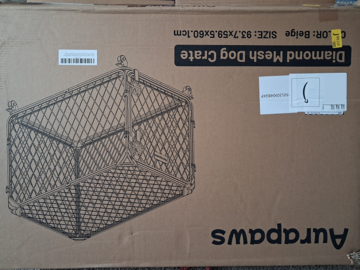

In [5]:
og_img = Image.open(f"{root}/5672.jpg")
thumbnail = og_img.copy()
thumbnail.thumbnail((610, 270))
thumbnail

In [6]:
results = model.predict(
    source=og_img,
    save=True,
    project="barcode_localization",
    name="yolov26m-obj")


0: 480x640 1 suitcase, 29.9ms
Speed: 88.2ms preprocess, 29.9ms inference, 37.1ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/barcode_localization/yolov26m-obj


The off-the-shelf object detection model does not detect any of the barcodes. Instead, it thinks the image contains a suitcase!

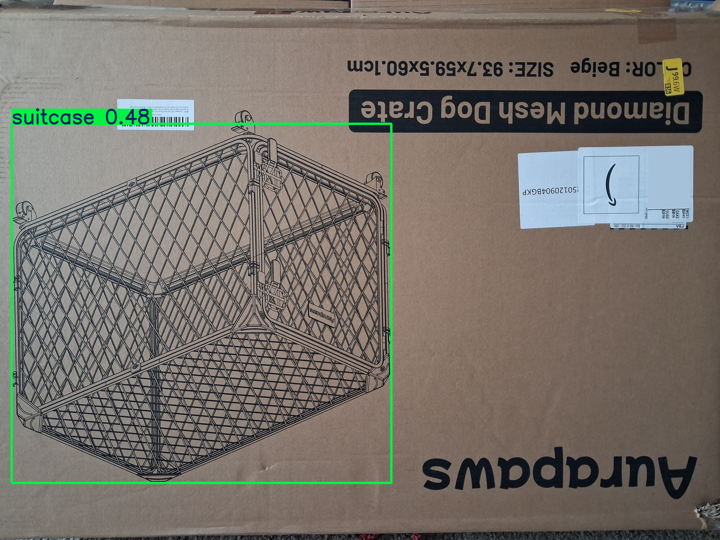

In [7]:
res_img = Image.open(f"/content/runs/detect/barcode_localization/yolov26m-obj/5672.jpg")
res_img.thumbnail((1020, 540))
res_img

### yolov26 Instance Segmentation

In [8]:
model = YOLO(local_model_paths[1])

In [9]:
results = model.predict(
    source=og_img,
    save=True,
    project="barcode_localization",
    name="yolov26m-seg")


0: 480x640 1 umbrella, 42.3ms
Speed: 2.8ms preprocess, 42.3ms inference, 31.8ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/segment/barcode_localization/yolov26m-seg


Instance segmentation always produces a pretty picture, but unfortunately, the model thinks this is an umbrella!

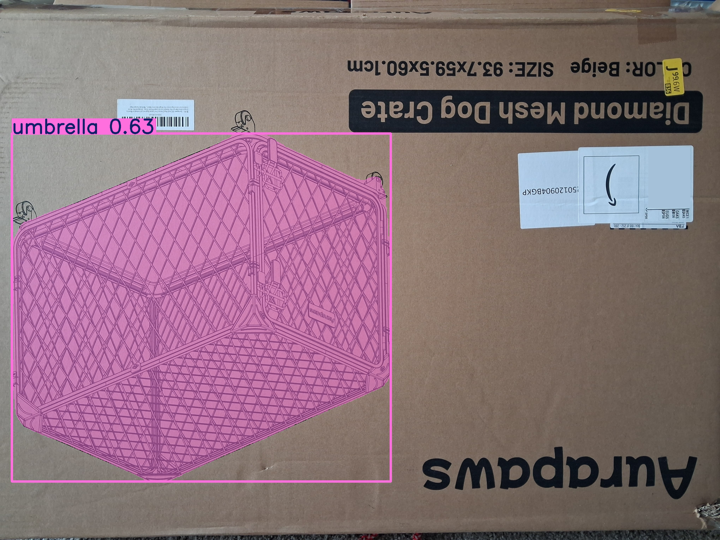

In [10]:
res_img = Image.open(f"/content/runs/segment/barcode_localization/yolov26m-seg/5672.jpg")
res_img.thumbnail((1020, 540))
res_img

## Finding open weights barcode detection models

ChatGPT found me a barcode detection YOLOv8 model on HuggingFace: [Piero2411/YOLOV8s-Barcode-Detection](https://huggingface.co/Piero2411/YOLOV8s-Barcode-Detection?utm_source=chatgpt.com). Let's try it out!

In [11]:
model = YOLO(local_model_paths[2])

In [12]:
results = model.predict(
    source=og_img,
    save=True,
    project="barcode_localization",
    name="YOLOV8s_Barcode_Detection")


0: 480x640 2 barcodes, 12.8ms
Speed: 2.2ms preprocess, 12.8ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/barcode_localization/YOLOV8s_Barcode_Detection


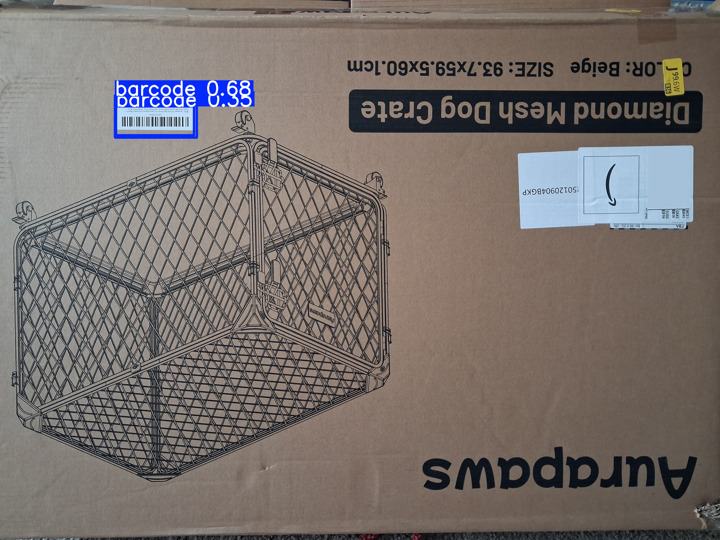

In [13]:
res_img = Image.open(f"/content/runs/detect/barcode_localization/YOLOV8s_Barcode_Detection/5672.jpg")
res_img.thumbnail((1020, 540))
res_img

Nice!!

## OpenCV Barcode Decoder

In [14]:
detector = cv2.barcode.BarcodeDetector()

Do we need to crop our barcode out of the original image? Yes, but let's see what happens if we don't.

In [15]:
og_img_arr = cv2.imread(f"{root}/5672.jpg")
og_img_arr .shape

(3060, 4080, 3)

In [16]:
ok, points = detector.detect(og_img_arr)
ok, points

(False, None)

Okay, let's crop the image.

The model outputs have two classes: barcode and QR code.

In [17]:
results[0].names

{0: 'barcode', 1: 'qrcode'}

The model detected two boxes, both are of class "barcode". The first one with decent confidence.

In [18]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0., 0.], device='cuda:0')
conf: tensor([0.6752, 0.3472], device='cuda:0')
data: tensor([[6.5193e+02, 5.4089e+02, 1.1152e+03, 7.7961e+02, 6.7523e-01, 0.0000e+00],
        [6.5786e+02, 6.0271e+02, 1.0993e+03, 7.6676e+02, 3.4720e-01, 0.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (3060, 4080)
shape: torch.Size([2, 6])
xywh: tensor([[883.5412, 660.2487, 463.2318, 238.7156],
        [878.5609, 684.7345, 441.4030, 164.0570]], device='cuda:0')
xywhn: tensor([[0.2166, 0.2158, 0.1135, 0.0780],
        [0.2153, 0.2238, 0.1082, 0.0536]], device='cuda:0')
xyxy: tensor([[ 651.9253,  540.8909, 1115.1571,  779.6065],
        [ 657.8594,  602.7060, 1099.2625,  766.7630]], device='cuda:0')
xyxyn: tensor([[0.1598, 0.1768, 0.2733, 0.2548],
        [0.1612, 0.1970, 0.2694, 0.2506]], device='cuda:0')

In [19]:
results[0].boxes.conf

tensor([0.6752, 0.3472], device='cuda:0')

In [20]:
results[0].boxes.cls

tensor([0., 0.], device='cuda:0')

We will grab the first of these two tensors in xyxy format.

In [21]:
results[0].boxes.data.shape

torch.Size([2, 6])

In [22]:
results[0].boxes.data[0]

tensor([6.5193e+02, 5.4089e+02, 1.1152e+03, 7.7961e+02, 6.7523e-01, 0.0000e+00], device='cuda:0')

In [23]:
results[0].boxes.xyxy[0]

tensor([ 651.9253,  540.8909, 1115.1571,  779.6065], device='cuda:0')

Let's crop.

In [24]:
x1, y1, x2, y2 = results[0].boxes.xyxy[0]
barcode_arr = og_img_arr[int(y1):int(y2), int(x1):int(x2)]

In [25]:
barcode_arr.shape

(239, 464, 3)

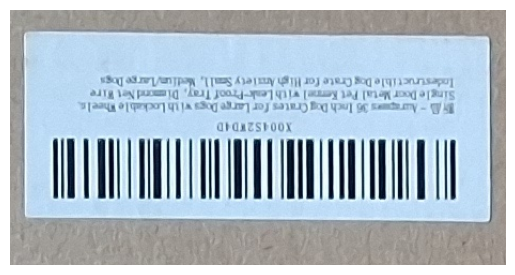

In [26]:
plt.imshow(cv2.cvtColor(barcode_arr, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Pretty! Let's try to detect and decode it.

In [27]:
ok, points = detector.detect(barcode_arr)
ok

True

Nice!

In [28]:
points.shape

(1, 4, 2)

In [29]:
points

array([[[    -3.4321,      178.36],
        [    -3.7599,      122.36],
        [     459.43,      119.64],
        [     459.76,      175.64]]], dtype=float32)

In [30]:
ok, decoded_info, decoded_type = detector.decodeWithType(
    barcode_arr, points
)

In [31]:
ok, decoded_info, decoded_type

(False, ('',), ('',))

I read online that OpenCV has a high-resolution model for small and low-quality barcodes, so let's try that.

In [32]:
detector = cv2.barcode.BarcodeDetector(
    f"{root}/sr.prototxt",
    f"{root}/sr.caffemodel"
)

In [33]:
ok, points = detector.detect(barcode_arr)
ok

True

In [34]:
ok, decoded_info, decoded_type = detector.decodeWithType(
    barcode_arr, points
)
ok, decoded_info, decoded_type

(False, ('',), ('',))

Why is it not able to decode the barcode even though it detects? One hypothesis: the barcode is too small! I'll take a closer picture with my camera.

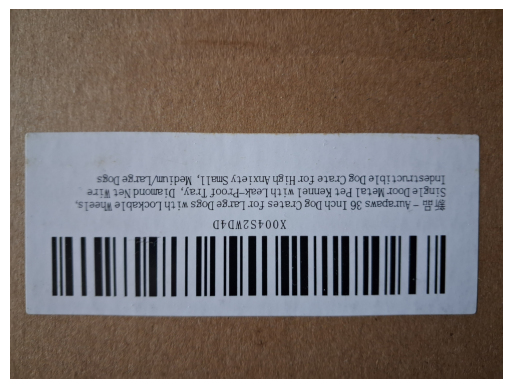

In [35]:
closer_barcode_arr = cv2.imread(f'{root}/closer.jpg')
plt.imshow(cv2.cvtColor(closer_barcode_arr, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [36]:
ok, points = detector.detect(closer_barcode_arr)
ok

True

In [37]:
ok, decoded_info, decoded_type = detector.decodeWithType(
    closer_barcode_arr, points
)
ok, decoded_info, decoded_type

(False, ('', ''), ('', ''))

Nope, that didn't do it.

Opus thinks that it's a barcode type issue. Not all barcodes use the same standard, and OpenCV might not be compatible with the barcode in this image, which is why it's detecting it but not able to decode it.

In [38]:
from pyzbar.pyzbar import decode

gray = cv2.cvtColor(closer_barcode_arr, cv2.COLOR_BGR2GRAY)

for d in decode(gray):
    print(d.type, "->", d.data.decode("utf-8"), "@", d.rect)

In [39]:
decode(gray)

[]

pyzbar is unable to decode it as well. What if we tried the full-size image?

In [40]:
og_img_arr = cv2.imread(f"{root}/5672.jpg")
gray = cv2.cvtColor(og_img_arr, cv2.COLOR_BGR2GRAY)

for d in decode(gray):
    print(d.type, "->", d.data.decode("utf-8"), "@", d.rect)

CODE128 -> X004S2WD4D @ Rect(left=699, top=664, width=364, height=52)


Whoa. Pyzbar decodes the full-size image where the barcode is tiny, but it's not able to decode the full-size zoomed-in image where the barcode is huge. A note on the barcode type: [it's Code 128, which is a barcode standard not supported by OpenCV](https://docs.opencv.org/4.9.0/d6/d25/tutorial_barcode_detect_and_decode.html#:~:text=Currently%2C%20we%20support%20EAN%2D8%2C%20EAN%2D13%2C%20UPC%2DA%20and%20UPC%2DE%20standards.).

The decoded result also shows the pixel location of the barcode, and conveniently, it also shows that it is an upside-down barcode with an orientation of 'DOWN'.

In [41]:
d

Decoded(data=b'X004S2WD4D', type='CODE128', rect=Rect(left=699, top=664, width=364, height=52), polygon=[Point(x=699, y=665), Point(x=699, y=715), Point(x=1063, y=716), Point(x=1063, y=664)], quality=45, orientation='DOWN')

Back to the resolution issue: why did PyZBar decode the full-size image where the barcode is tiny, but not the full-size zoomed-in image where the barcode is huge? Opus was able to [find the answer in their docs](https://github.com/ZBar/ZBar/blob/master/iphone/doc/optimizing.rst). It turns out that more is not better when it comes to barcode decoding:

> One might think that "more is better" in terms of resolution, but this is not necessarily the case. Given average image quality, the ideal resolution for scanning is right around three pixels per barcode "module" (the width of the smallest bar or space). Note that this measure is not an absolute image size or even a measure of the physical dimensions represented by a pixel sample, it only describes the sampled size of the barcode in the image.

This is a textbook example of how the logic of human perception (let me lean in closer to better read the barcode) does not always translate to machine perception (let's make sure we only have 3 pixels per barcode module).

Let's resize the close-up image and see if we get a result.

In [42]:
gray = cv2.cvtColor(closer_barcode_arr, cv2.COLOR_BGR2GRAY)
h, w = gray.shape
scale = 800 / max(h, w)
small = cv2.resize(gray, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)
small.shape

(600, 800)

In [43]:
decode(small)

[Decoded(data=b'X004S2WD4D', type='CODE128', rect=Rect(left=81, top=370, width=618, height=91), polygon=[Point(x=81, y=371), Point(x=81, y=411), Point(x=82, y=461), Point(x=697, y=460), Point(x=698, y=436), Point(x=699, y=374), Point(x=699, y=370)], quality=79, orientation='DOWN')]

What happens if we use the cropped barcode from the YOLOv8 localization?

In [44]:
decode(cv2.cvtColor(barcode_arr, cv2.COLOR_BGR2GRAY))

[Decoded(data=b'X004S2WD4D', type='CODE128', rect=Rect(left=48, top=124, width=364, height=52), polygon=[Point(x=48, y=125), Point(x=48, y=175), Point(x=412, y=176), Point(x=412, y=124)], quality=33, orientation='DOWN')]

## Do we need localization?

Let's summarize the results first. To do so, I'm going to write some helper functions to clean up the code.

In [45]:
def localize_barcode(img, model_path="/content/ultralytics_models/YOLOV8s_Barcode_Detection.pt"):
    model = YOLO(model_path)
    results = model.predict(
        source=img,
        save=True,
        project="barcode_localization",
        name="YOLOV8s_Barcode_Detection"
        )
    return results

In [46]:
def _pyzbar_decode(img_arr):
    if len(img_arr.shape) == 2:
        return decode(img_arr)
    gray = cv2.cvtColor(img_arr, cv2.COLOR_BGR2GRAY)
    return pyzbar_decode(gray)

In [47]:
def get_localized_barcode_arr(img_path, conf_thresh=0.5):
    img = Image.open(img_path)
    results = localize_barcode(img)
    img_arr = cv2.imread(img_path)
    results[0].boxes.xyxy[results[0].boxes.conf > conf_thresh]
    x1, y1, x2, y2 = results[0].boxes.xyxy[0]
    barcode_arr = img_arr[int(y1):int(y2), int(x1):int(x2)]
    plt.imshow(cv2.cvtColor(barcode_arr, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()
    return barcode_arr

In [48]:
def smaller_barcode(closer_barcode_arr, scale_numerator=800):
    h, w, c = closer_barcode_arr.shape
    scale = scale_numerator / max(h, w)
    small = cv2.resize(closer_barcode_arr, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)
    return small

In [49]:
og_decode = _pyzbar_decode(cv2.imread(f"{root}/5672.jpg"))
og_decode

[Decoded(data=b'X004S2WD4D', type='CODE128', rect=Rect(left=699, top=664, width=364, height=52), polygon=[Point(x=699, y=665), Point(x=699, y=715), Point(x=1063, y=716), Point(x=1063, y=664)], quality=45, orientation='DOWN')]

In [50]:
closer_decode = _pyzbar_decode(cv2.imread(f'{root}/closer.jpg'))
closer_decode

[]


0: 480x640 2 barcodes, 12.8ms
Speed: 2.3ms preprocess, 12.8ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/barcode_localization/YOLOV8s_Barcode_Detection-2


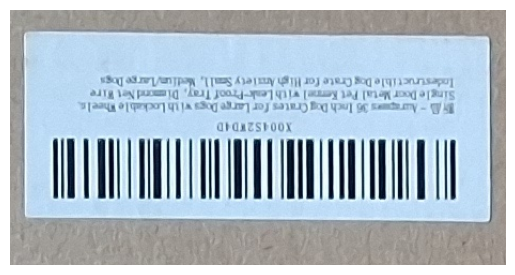

In [51]:
barcode_arr = get_localized_barcode_arr(f"{root}/5672.jpg")

In [52]:
localized_decode = _pyzbar_decode(barcode_arr)
localized_decode

[Decoded(data=b'X004S2WD4D', type='CODE128', rect=Rect(left=48, top=124, width=364, height=52), polygon=[Point(x=48, y=125), Point(x=48, y=175), Point(x=412, y=176), Point(x=412, y=124)], quality=33, orientation='DOWN')]

In [53]:
smaller_closer_barcode_arr = smaller_barcode(cv2.imread(f'{root}/closer.jpg'))
smaller_closer_barcode_decode = _pyzbar_decode(smaller_closer_barcode_arr)
smaller_closer_barcode_decode

[Decoded(data=b'X004S2WD4D', type='CODE128', rect=Rect(left=81, top=369, width=618, height=92), polygon=[Point(x=81, y=369), Point(x=81, y=411), Point(x=82, y=461), Point(x=697, y=460), Point(x=698, y=436), Point(x=699, y=374), Point(x=699, y=370)], quality=81, orientation='DOWN')]

From the ZBar docs, quality is:

> ...an unscaled, relative quantity: larger values are better than smaller values, where "large" and "small" are application dependent. Expect the exact definition of this quantity to change as the metric is refined. currently, only the ordered relationship between two values is defined and will remain stable in the future

In [54]:
localized_decode[0].quality

33

In [55]:
og_decode[0].quality

45

In [56]:
closer_decode

[]

In [57]:
smaller_closer_barcode_decode[0].quality

81

In terms of quality, here are the final rankings:

1. downsized close-up image of barcode.
2. image of full package.
3. localized bar code from image of full package.

Not Ranked: full size close-up image of barcode.

Based on this experiment with a sample size of one, I have two takeaways from these decode quality results:

- it's most important to have the right scale of barcode modules (bar and space pixel width less than ~3)
- it's better to start with a *higher-resolution image of the barcode* and resize it without localization than it is to *localize a low-resolution barcode from a larger image*.

## Engineering Implications

Is there a machine learning application that is not fascinating? Even barcodes are wondrous.

Let's assume these results held for a larger set of real, production images.

The original paper that inspired this experiment was on UAV-based warehouse inventory management systems. When I look at these results, where localization doesn't matter as much as high-resolution barcode images, I would want to consider the following in the following order:

- Check if lower-quality decoding is acceptable (maybe `og_decode` quality of 45 is fine)
- Move the drone closer to the rack before taking images (e.g. `closer.jpg`)
- Get the drone a better camera
- Improve the barcode decoder (e.g. change the config, try another library)

I would try all of that **before fine-tuning my own latest YOLO model for barcode object detection**.

Computer vision are models and algorithms are susceptible to anthropomorphization, just like LLMs are. It's tempting to think that computer vision models and algorithms care about human visual perception. What is good or bad data in terms of quality, and what quality even means, has to be validated through experimentation, and looking at the resulting data. Just because an image seems "better quality" to a human looking at it does not mean it's better quality for a CV algorithm or model.

While this notebook is extremely trivial and barely a proof of concept, you would be surprised (or maybe you wouldn't?) how often assumptions about image quality from a human's perception drive production engineering decisions.